# EduBot Analytics — TP1: Análise Exploratória de Dados (EDA)

**Disciplina:** Projeto de Bloco: Análise e Segurança de Agentes de IA
**Professor:** Ricardo Pires Mesquita
**Aluna A (Dados/IA):** Maitê Mota Belo de Souza Silva
**Aluna B (Infra/Sec):** Patricia Dias Rodrigues

---

## Objetivo deste notebook

O EduBot Analytics é um agente de suporte acadêmico universitário. A partir de uma mensagem
escrita por um aluno, ele precisa decidir:

1. **Qual a categoria do pedido** (matrícula, trancamento, financeiro, acesso, feedback...) —
   pra direcionar ao protocolo certo;
2. **Qual o nível de urgência/tom** — pra priorizar a fila.

Este notebook é a etapa anterior a qualquer modelo: entender os dados que vão treinar o agente.
Não tem treinamento aqui (isso é TP3/TP4).

O notebook está organizado em:

1. Carga e inspeção estrutural do dataset bruto
2. Qualidade dos dados (ausentes, duplicatas, cardinalidade)
3. Distribuição das categorias e intenções originais
4. **Adaptação de domínio** — remapeamento do dataset para o vocabulário do EduBot
5. Engenharia de atributos (comprimento e tags linguísticas)
6. Visualizações
7. Hipóteses sobre as intenções dos usuários
8. Exportação do dataset tratado e limitações conhecidas


---
## 1. Carga e inspeção estrutural

### 1.1 Escolha do dataset

**Nome:** Bitext — Customer Service Tagged Training Dataset for LLM-based Virtual Assistants
**Fonte:** Bitext Innovations (2024) — espelhos oficiais no Hugging Face e no GitHub
**Link (HF):** https://huggingface.co/datasets/bitext/Bitext-customer-support-llm-chatbot-training-dataset
**Link (GitHub):** https://github.com/bitext/customer-support-llm-chatbot-training-dataset
**Licença:** Community Data License Agreement — Sharing, Version 1.0 (CDLA-Sharing-1.0).
Permite uso, modificação e redistribuição, exigindo **atribuição** e que derivados sejam
compartilhados sob a mesma licença. A cópia integral da licença está em
`data/LICENSE-CDLA-Sharing-1.0.txt`.
**Arquivo:** `data/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv`

### 1.2 Justificativa da escolha

A justificativa completa, alternativas descartadas e detalhes da licença estão em
`escolha-do-dataset.md`. Resumo:

- **Bitext**, 26.872 registros, colunas `instruction` + `category`/`intent` — bate com o que o TP pede.
- A Bitext declara que estas intenções existem nos 20 verticais deles, **incluindo Educação**.
  Cancelar pedido ≈ trancar disciplina; consultar cobrança ≈ consultar boleto. Mapeio os rótulos
  na seção 4; as frases continuam em inglês.
- A coluna `flags` marca typo, coloquialismo, ofensa etc. — útil pro eixo de segurança (H3).

**Ressalva:** dataset híbrido sintético (NLG a partir de textos-semente), não tráfego real.
A distribuição uniforme de intenções é artificial — discuto na seção 8.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

CSV = DATA_DIR / "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv"

df_raw = pd.read_csv(CSV)
print(f"Dataset carregado: {CSV}")
print(f"Versoes -> pandas {pd.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}")

Dataset carregado: data/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv
Versoes -> pandas 3.0.2 | numpy 2.4.4 | matplotlib 3.10.8


### 1.3 Shape e dtypes

Primeira checagem: quantas linhas/colunas e o tipo de cada uma.

In [2]:
print("shape (linhas, colunas):", df_raw.shape)
print()
print("dtypes:")
print(df_raw.dtypes)
print()
print("memoria em uso:", f"{df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

shape (linhas, colunas): (26872, 5)

dtypes:
flags          str
instruction    str
category       str
intent         str
response       str
dtype: object

memoria em uso: 24.5 MB


In [3]:
df_raw.head(5)

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding canceling order {{Order Number...
1,BQZ,i have a question about cancelling oorder {{Order Number}},ORDER,cancel_order,I've been informed that you have a question about canceling order {{Order Nu...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance with canceling your purchase with...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with canceling your purchase with the ...
4,BCELN,"I cannot afford this order, cancel purchase {{Order Number}}",ORDER,cancel_order,I'm sensitive to the fact that you're facing financial difficulties and need...


Todas as colunas são textuais (`object`/`str`). Não há nenhuma variável numérica no dataset
bruto — o que significa que `describe()` no modo padrão não retorna estatística útil. Por isso
usamos `describe(include="all")`, que para colunas categóricas devolve contagem, cardinalidade,
valor mais frequente e sua frequência.

In [4]:
df_raw.describe(include="all").T

,count,unique,top,freq
flags,26872,394,BL,5212
instruction,26872,24635,do you ship to {{Delivery City}}?,8
category,26872,11,ACCOUNT,5986
intent,26872,27,check_invoice,1000
response,26872,26870,"Firstly, I truly understand how pivotal the {{Currency Symbol}}{{Refund Amou...",2


Leitura da tabela acima:

- `instruction` tem cardinalidade alta mas **não é única** — há repetições, tratadas na seção 2.
- `category` tem 11 valores distintos e `intent` tem 27: essa é a hierarquia de rótulos.
- `flags` tem 394 combinações distintas, porque é uma string de letras concatenadas
  (ex.: `BLQZ` = Básico + variação Lexical + Coloquial + erro de digitaÇão). Cada letra é uma tag
  independente, e por isso a coluna precisa ser explodida em variáveis binárias (seção 5).


---
## 2. Qualidade dos dados

Três verificações: valores ausentes, duplicatas e registros degenerados (texto vazio ou
excessivamente curto).

In [5]:
ausentes = pd.DataFrame({
    "n_ausentes": df_raw.isna().sum(),
    "pct_ausentes": (df_raw.isna().mean() * 100).round(2),
})
print("VALORES AUSENTES")
print(ausentes)
print()
vazios = (df_raw.select_dtypes(include="object").apply(lambda s: s.astype(str).str.strip().eq("").sum()))
print("STRINGS VAZIAS (apos strip)")
print(vazios)

VALORES AUSENTES
             n_ausentes  pct_ausentes
flags                 0           0.0
instruction           0           0.0
category              0           0.0
intent                0           0.0
response              0           0.0

STRINGS VAZIAS (apos strip)
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64


/tmp/ipykernel_520/936665694.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  vazios = (df_raw.select_dtypes(include="object").apply(lambda s: s.astype(str).str.strip().eq("").sum()))


**Valores ausentes:** nada a fazer — zero nulos e zero strings vazias. Coerente com dataset
sintético; em produção real, campos em branco seriam comuns.

In [6]:
dup_linha_inteira = df_raw.duplicated().sum()
dup_instruction = df_raw.duplicated(subset=["instruction"]).sum()
dup_instr_intent = df_raw.duplicated(subset=["instruction", "intent"]).sum()

print(f"Linhas 100% duplicadas (todas as colunas): {dup_linha_inteira}")
print(f"'instruction' duplicada:                   {dup_instruction} ({dup_instruction/len(df_raw)*100:.1f}%)")
print(f"par ('instruction','intent') duplicado:    {dup_instr_intent}")

Linhas 100% duplicadas (todas as colunas): 0
'instruction' duplicada:                   2237 (8.3%)
par ('instruction','intent') duplicado:    2237


O número que importa é o par (`instruction`, `intent`) repetido: mesma frase, mesmo rótulo,
só muda a `response` gerada. Pra classificação de intenção, isso não acrescenta nada — só infla
o peso de certas frases.

Antes de remover, chequei o caso ruim: mesma frase com rótulos **diferentes**. Seria ruído de
rotulação. (Não encontrei nenhum.)

In [7]:
conflitos = (
    df_raw.groupby("instruction")["intent"]
    .nunique()
    .loc[lambda s: s > 1]
    .sort_values(ascending=False)
)
print(f"Frases com MAIS DE UM intent atribuido: {len(conflitos)}")
if len(conflitos):
    print()
    print(conflitos.head(10))
    exemplo = conflitos.index[0]
    print()
    print(f"Exemplo -> {exemplo!r}")
    print(df_raw.loc[df_raw["instruction"] == exemplo, ["instruction", "category", "intent"]].drop_duplicates().to_string(index=False))

Frases com MAIS DE UM intent atribuido: 0


**Duplicatas:** removi repetições do par (`instruction`, `intent`), mantendo a primeira
ocorrência. Não encontrei frases com rótulos conflitantes (mesma frase, intents diferentes).

In [8]:
df = df_raw.drop_duplicates(subset=["instruction", "intent"], keep="first").copy()
print(f"Antes:  {len(df_raw):>6} registros")
print(f"Depois: {len(df):>6} registros  (removidos: {len(df_raw) - len(df)})")

Antes:   26872 registros
Depois:  24635 registros  (removidos: 2237)


---
## 3. Distribuição das categorias e intenções originais

Antes de remapear para o domínio acadêmico, é preciso enxergar como o dataset original está
distribuído.

In [9]:
dist_cat = df["category"].value_counts()
dist_cat_pct = (df["category"].value_counts(normalize=True) * 100).round(2)

tabela_cat = pd.DataFrame({"n": dist_cat, "pct": dist_cat_pct})
print("DISTRIBUICAO POR CATEGORIA (original)")
print(tabela_cat.to_string())
print()
print(f"Razao de desbalanceamento (maior/menor): {dist_cat.max() / dist_cat.min():.2f}x")

DISTRIBUICAO POR CATEGORIA (original)
                 n    pct
category                 
ACCOUNT       5443  22.09
ORDER         3168  12.86
REFUND        2622  10.64
CONTACT       1999   8.11
PAYMENT       1998   8.11
FEEDBACK      1997   8.11
SHIPPING      1970   8.00
INVOICE       1830   7.43
DELIVERY      1659   6.73
SUBSCRIPTION   999   4.06
CANCEL         950   3.86

Razao de desbalanceamento (maior/menor): 5.73x


In [10]:
dist_int = df["intent"].value_counts()
print("DISTRIBUICAO POR INTENT (original) - 27 intents")
print(dist_int.to_string())
print()
print(f"Razao de desbalanceamento (maior/menor): {dist_int.max() / dist_int.min():.2f}x")

DISTRIBUICAO POR INTENT (original) - 27 intents
intent
complaint                   1000
contact_customer_service    1000
check_payment_methods        999
contact_human_agent          999
delivery_period              999
newsletter_subscription      999
payment_issue                999
registration_problems        999
place_order                  998
check_refund_policy          997
review                       997
set_up_shipping_address      997
recover_password             995
change_shipping_address      973
check_cancellation_fee       950
check_invoice                921
delete_account               918
get_refund                   918
get_invoice                  909
create_account               892
change_order                 870
switch_account               862
track_order                  807
edit_account                 777
track_refund                 707
delivery_options             660
cancel_order                 493

Razao de desbalanceamento (maior/menor): 2.03x


In [11]:
# Quanto cada intent perdeu na deduplicacao?
taxa_dup = (1 - df["intent"].value_counts() / df_raw["intent"].value_counts()).mul(100).round(1)
taxa_dup = taxa_dup.sort_values(ascending=False)
print("TAXA DE DUPLICACAO POR INTENT (%) - maiores e menores")
print(taxa_dup.head(6).to_string())
print("   ...")
print(taxa_dup.tail(4).to_string())

TAXA DE DUPLICACAO POR INTENT (%) - maiores e menores
intent
cancel_order        50.6
delivery_options    33.7
track_refund        29.2
edit_account        22.3
track_order         18.9
switch_account      13.8
   ...
intent
review                     0.0
registration_problems      0.0
recover_password           0.0
set_up_shipping_address    0.0


**Observação sobre desbalanceamento.** No bruto, cada intenção tem ~1.000 amostras (geração
controlada). Depois da deduplicação, isso quebra: `cancel_order` perdeu metade das frases
repetidas, enquanto outras (`review`, `recover_password`) não tinham nenhuma duplicata.

Faz sentido: intenções com vocabulário restrito ("cancelar pedido X") esgotam as variações
rápido; intenções mais abertas ("problema no cadastro") geram frases distintas. Na prática,
`disciplina_trancar` fica com metade das amostras das demais — preciso considerar isso na
amostragem do TP3.

O desbalanceamento por `category` é só porque ACCOUNT agrupa 6 intenções e CANCEL agrupa 1.

Limitação: um modelo treinado aqui assume demanda uniforme, o que não bate com a realidade
(rematrícula concentra tudo em matrícula e nota).

---
## 4. Adaptação de domínio: de suporte genérico para EduBot Analytics

O dataset usa vocabulário de e-commerce (`order`, `invoice`, `shipping`). O EduBot fala de
matrícula, trancamento, notas e financeiro.

A Bitext diz que estas intenções existem nos 20 verticais deles, Educação incluída. Então o
remapeamento é trocar o rótulo, não inventar intenção nova — detalhes na tabela abaixo.

### 4.1 Regra de mapeamento

Cada `intent` original ganha:

- `intent_edubot` — nome no vocabulário acadêmico;
- `categoria_edubot` — categoria de roteamento;
- `natureza` — burocrático / acadêmico / relacional.

**Descarte:** quatro intenções puramente logísticas (`delivery_period`, `delivery_options`,
`set_up_shipping_address`, `change_shipping_address`) não têm equivalente acadêmico. Removi
essas linhas; o volume descartado está abaixo.

In [12]:
MAPA = {
    # --- Vida academica: matricula, inscricao, trancamento, acompanhamento ---
    "create_account":           ("matricula_solicitar",              "ACADEMICO",  "academico"),
    "registration_problems":    ("matricula_problema",               "ACADEMICO",  "academico"),
    "place_order":              ("disciplina_inscrever",             "ACADEMICO",  "academico"),
    "change_order":             ("disciplina_alterar",               "ACADEMICO",  "academico"),
    "cancel_order":             ("disciplina_trancar",               "ACADEMICO",  "academico"),
    "check_cancellation_fee":   ("trancamento_consultar_regra",      "ACADEMICO",  "academico"),
    "track_order":              ("solicitacao_consultar_status",     "ACADEMICO",  "academico"),

    # --- Cadastro e vinculo do aluno (superficie critica de IDOR) ---
    "edit_account":             ("cadastro_atualizar_dados",         "CADASTRO",   "burocratico"),
    "delete_account":           ("cadastro_cancelar_vinculo",        "CADASTRO",   "burocratico"),
    "switch_account":           ("cadastro_trocar_vinculo",          "CADASTRO",   "burocratico"),

    # --- Acesso ao portal ---
    "recover_password":         ("acesso_recuperar_senha",           "ACESSO",     "burocratico"),

    # --- Financeiro / secretaria ---
    "check_invoice":            ("financeiro_consultar_boleto",      "FINANCEIRO", "burocratico"),
    "get_invoice":              ("financeiro_emitir_boleto",         "FINANCEIRO", "burocratico"),
    "check_payment_methods":    ("financeiro_formas_pagamento",      "FINANCEIRO", "burocratico"),
    "payment_issue":            ("financeiro_problema_pagamento",    "FINANCEIRO", "burocratico"),
    "get_refund":               ("financeiro_solicitar_reembolso",   "FINANCEIRO", "burocratico"),
    "track_refund":             ("financeiro_acompanhar_reembolso",  "FINANCEIRO", "burocratico"),
    "check_refund_policy":      ("financeiro_politica_reembolso",    "FINANCEIRO", "burocratico"),

    # --- Feedback e suporte humano ---
    "complaint":                ("feedback_reclamacao",              "FEEDBACK",   "relacional"),
    "review":                   ("feedback_avaliacao",               "FEEDBACK",   "relacional"),
    "contact_customer_service": ("suporte_contato_secretaria",       "SUPORTE",    "relacional"),
    "contact_human_agent":      ("suporte_atendente_humano",         "SUPORTE",    "relacional"),
    "newsletter_subscription":  ("suporte_comunicados",              "SUPORTE",    "relacional"),
}

DESCARTADAS = ["delivery_period", "delivery_options",
               "set_up_shipping_address", "change_shipping_address"]

# Sanidade: todo intent original precisa estar mapeado OU explicitamente descartado
originais = set(df["intent"].unique())
cobertos = set(MAPA) | set(DESCARTADAS)
assert originais == cobertos, f"Intents nao tratados: {originais ^ cobertos}"
print(f"OK - {len(originais)} intents originais: {len(MAPA)} mapeados, {len(DESCARTADAS)} descartados.")

OK - 27 intents originais: 23 mapeados, 4 descartados.


In [13]:
n_antes = len(df)
descartadas_n = df["intent"].isin(DESCARTADAS).sum()

df = df[~df["intent"].isin(DESCARTADAS)].copy()

df["intent_edubot"]    = df["intent"].map(lambda i: MAPA[i][0])
df["categoria_edubot"] = df["intent"].map(lambda i: MAPA[i][1])
df["natureza"]         = df["intent"].map(lambda i: MAPA[i][2])

print(f"Registros antes do descarte:  {n_antes}")
print(f"Registros logisticos removidos: {descartadas_n} ({descartadas_n/n_antes*100:.1f}%)")
print(f"Registros apos adaptacao:     {len(df)}")
print()
print(df[["instruction", "intent", "intent_edubot", "categoria_edubot", "natureza"]].sample(8, random_state=42).to_string(index=False))

Registros antes do descarte:  24635
Registros logisticos removidos: 3629 (14.7%)
Registros apos adaptacao:     21006

                                                 instruction                   intent               intent_edubot categoria_edubot    natureza
                       I cannot notify of issues with signup    registration_problems          matricula_problema        ACADEMICO   academico
                       I try to check the payment modalities    check_payment_methods financeiro_formas_pagamento       FINANCEIRO burocratico
                       need help to check ur payment methods    check_payment_methods financeiro_formas_pagamento       FINANCEIRO burocratico
need assistance to make a consumer claim against ur business                complaint         feedback_reclamacao         FEEDBACK  relacional
 I want to check at what time I can call customer assistance contact_customer_service  suporte_contato_secretaria          SUPORTE  relacional
                I am try

In [14]:
dist_edu = pd.DataFrame({
    "n": df["categoria_edubot"].value_counts(),
    "pct": (df["categoria_edubot"].value_counts(normalize=True) * 100).round(2),
})
print("DISTRIBUICAO POR CATEGORIA EDUBOT")
print(dist_edu.to_string())
print()
print(f"Razao de desbalanceamento: {dist_edu['n'].max() / dist_edu['n'].min():.2f}x")
print()
print("DISTRIBUICAO POR NATUREZA")
print(pd.DataFrame({
    "n": df["natureza"].value_counts(),
    "pct": (df["natureza"].value_counts(normalize=True) * 100).round(2),
}).to_string())

DISTRIBUICAO POR CATEGORIA EDUBOT
                     n    pct
categoria_edubot             
FINANCEIRO        6450  30.71
ACADEMICO         6009  28.61
SUPORTE           2998  14.27
CADASTRO          2557  12.17
FEEDBACK          1997   9.51
ACESSO             995   4.74

Razao de desbalanceamento: 6.48x

DISTRIBUICAO POR NATUREZA
                 n    pct
natureza                 
burocratico  10002  47.61
academico     6009  28.61
relacional    4995  23.78


---
## 5. Engenharia de atributos

Duas famílias de atributos derivados, ambas úteis tanto para o classificador quanto para a
análise de segurança:

**(a) Comprimento da mensagem** — número de caracteres e de palavras. Hipótese a testar: pedidos
que envolvem justificativa (reclamação, problema de pagamento) são mais longos que consultas
diretas.

**(b) Tags linguísticas** — a coluna `flags` é uma string de letras concatenadas, onde cada letra
é uma propriedade independente do texto. Explodimos em colunas binárias.

In [15]:
df["n_chars"]    = df["instruction"].str.len()
df["n_palavras"]  = df["instruction"].str.split().str.len()

print("ESTATISTICAS DE COMPRIMENTO")
print(df[["n_chars", "n_palavras"]].describe().round(2).to_string())

ESTATISTICAS DE COMPRIMENTO
        n_chars  n_palavras
count  21006.00    21006.00
mean      46.91        8.81
std       11.26        2.61
min        6.00        1.00
25%       39.00        7.00
50%       48.00        9.00
75%       55.00       11.00
max       92.00       16.00


In [16]:
# Frequencia bruta de cada tag linguistica
contagem_tags = Counter()
for s in df["flags"]:
    contagem_tags.update(set(s))

DESCRICAO_TAGS = {
    "B": "Estrutura sintatica basica",
    "I": "Estrutura interrogativa",
    "C": "Estrutura coordenada",
    "N": "Negacao",
    "M": "Variacao morfologica",
    "L": "Variacao lexical (sinonimos)",
    "P": "Registro polido",
    "Q": "Registro coloquial",
    "W": "Linguagem ofensiva",
    "K": "Modo palavra-chave",
    "E": "Uso de abreviacoes",
    "Z": "Erros de digitacao / pontuacao",
    "S": "Outra variacao estilistica",
    "V": "Outra variacao estilistica",
}

tabela_tags = (
    pd.DataFrame(
        [(t, DESCRICAO_TAGS.get(t, "nao documentada"), n, round(n / len(df) * 100, 2))
         for t, n in contagem_tags.items()],
        columns=["tag", "descricao", "n", "pct_das_mensagens"],
    )
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)
print("PREVALENCIA DAS TAGS LINGUISTICAS")
print(tabela_tags.to_string(index=False))

PREVALENCIA DAS TAGS LINGUISTICAS
tag                      descricao     n  pct_das_mensagens
  B     Estrutura sintatica basica 21006             100.00
  L   Variacao lexical (sinonimos) 19116              91.00
  Q             Registro coloquial  7415              35.30
  I        Estrutura interrogativa  6272              29.86
  Z Erros de digitacao / pontuacao  4149              19.75
  M           Variacao morfologica  4007              19.08
  C           Estrutura coordenada  2225              10.59
  E             Uso de abreviacoes  1640               7.81
  K             Modo palavra-chave  1459               6.95
  P                Registro polido  1109               5.28
  W             Linguagem ofensiva  1088               5.18
  N                        Negacao   408               1.94
  V     Outra variacao estilistica    77               0.37


In [17]:
# Explosao das tags de interesse em variaveis binarias
df["tem_ofensa"]     = df["flags"].str.contains("W")
df["tem_typo"]       = df["flags"].str.contains("Z")
df["tem_coloquial"]  = df["flags"].str.contains("Q")
df["tem_polidez"]    = df["flags"].str.contains("P")
df["tem_negacao"]    = df["flags"].str.contains("N")
df["modo_keyword"]   = df["flags"].str.contains("K")
df["tem_abreviacao"] = df["flags"].str.contains("E")

binarias = ["tem_ofensa", "tem_typo", "tem_coloquial", "tem_polidez",
            "tem_negacao", "modo_keyword", "tem_abreviacao"]
print(df[binarias].mean().mul(100).round(2).to_frame("pct_True").to_string())

                pct_True
tem_ofensa          5.18
tem_typo           19.75
tem_coloquial      35.30
tem_polidez         5.28
tem_negacao         1.94
modo_keyword        6.95
tem_abreviacao      7.81


### 5.1 Proxy de urgência

O EduBot precisa classificar urgência, mas **este dataset não tem rótulo de urgência** — só a
coluna `flags` com registro linguístico.

Montei um `urgencia_proxy` heurístico (explícito que é aproximação):

- `alta` — tag `W` (linguagem ofensiva);
- `baixa` — tag `P` (polidez) sem ofensa;
- `media` — resto.

Testo na H2 se isso funciona. Se não, no TP2 combino com dataset de emoção ou anoto manualmente.

In [18]:
def urgencia_proxy(flags: str) -> str:
    if "W" in flags:
        return "alta"
    if "P" in flags:
        return "baixa"
    return "media"

df["urgencia_proxy"] = df["flags"].apply(urgencia_proxy)

print(pd.DataFrame({
    "n": df["urgencia_proxy"].value_counts(),
    "pct": (df["urgencia_proxy"].value_counts(normalize=True) * 100).round(2),
}).to_string())

                    n    pct
urgencia_proxy              
media           18951  90.22
alta             1088   5.18
baixa             967   4.60


---
## 6. Visualizações

Seis visualizações, cobrindo distribuição de rótulos, distribuição de variáveis contínuas e
relação entre variáveis. Todas são salvas em `figures/` para poderem ser referenciadas no
relatório sem reexecutar o notebook.

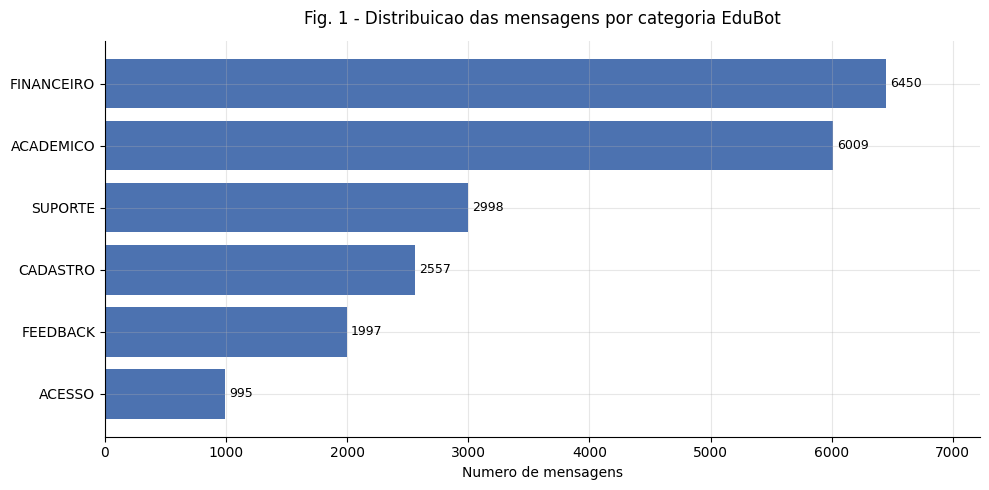

In [19]:
# --- FIG 1: distribuicao das categorias EduBot (barras) ---
fig, ax = plt.subplots(figsize=(10, 5))
d = df["categoria_edubot"].value_counts().sort_values()
barras = ax.barh(d.index, d.values, color="#4C72B0")
ax.bar_label(barras, padding=3, fontsize=9)
ax.set_title("Fig. 1 - Distribuicao das mensagens por categoria EduBot", fontsize=12, pad=12)
ax.set_xlabel("Numero de mensagens")
ax.set_xlim(0, d.max() * 1.12)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_distribuicao_categorias.png", dpi=120)
plt.show()

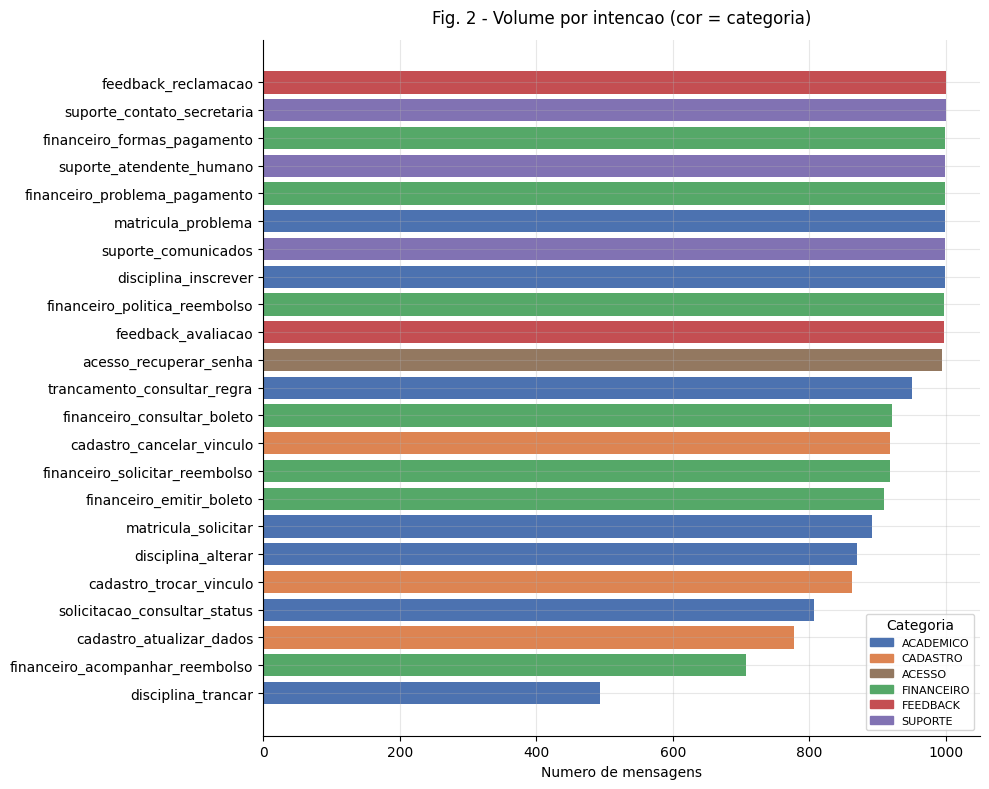

In [20]:
# --- FIG 2: distribuicao das 23 intencoes (barras) ---
fig, ax = plt.subplots(figsize=(10, 8))
d = df["intent_edubot"].value_counts().sort_values()
cores = {"ACADEMICO": "#4C72B0", "CADASTRO": "#DD8452", "ACESSO": "#937860",
         "FINANCEIRO": "#55A868", "FEEDBACK": "#C44E52", "SUPORTE": "#8172B3"}
mapa_cat = df.drop_duplicates("intent_edubot").set_index("intent_edubot")["categoria_edubot"]
ax.barh(d.index, d.values, color=[cores[mapa_cat[i]] for i in d.index])
ax.set_title("Fig. 2 - Volume por intencao (cor = categoria)", fontsize=12, pad=12)
ax.set_xlabel("Numero de mensagens")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in cores.values()]
ax.legend(handles, cores.keys(), fontsize=8, loc="lower right", title="Categoria")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_distribuicao_intents.png", dpi=120)
plt.show()

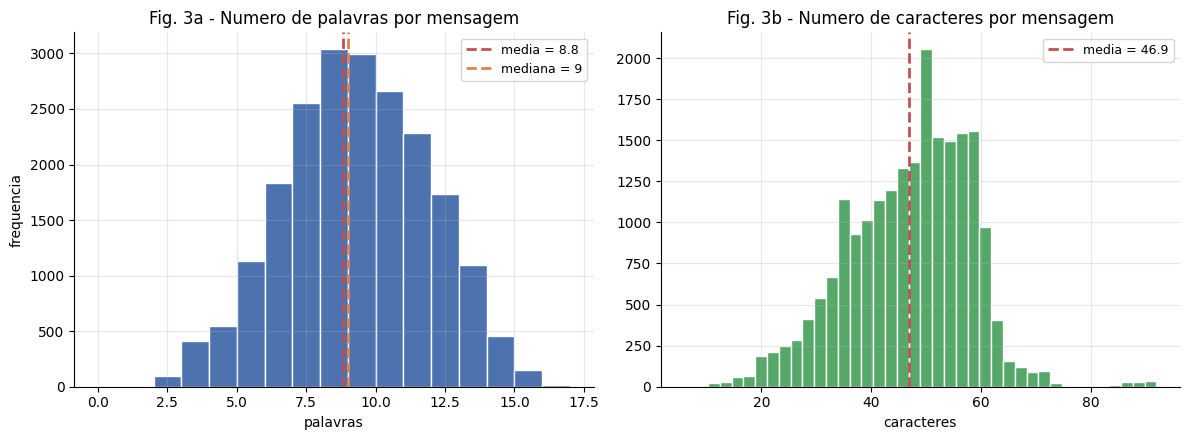

In [21]:
# --- FIG 3: histograma do comprimento das mensagens ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df["n_palavras"], bins=range(0, df["n_palavras"].max() + 2),
             color="#4C72B0", edgecolor="white")
axes[0].axvline(df["n_palavras"].mean(), color="#C44E52", linestyle="--", linewidth=2,
                label=f"media = {df['n_palavras'].mean():.1f}")
axes[0].axvline(df["n_palavras"].median(), color="#DD8452", linestyle="--", linewidth=2,
                label=f"mediana = {df['n_palavras'].median():.0f}")
axes[0].set_title("Fig. 3a - Numero de palavras por mensagem")
axes[0].set_xlabel("palavras"); axes[0].set_ylabel("frequencia"); axes[0].legend(fontsize=9)

axes[1].hist(df["n_chars"], bins=40, color="#55A868", edgecolor="white")
axes[1].axvline(df["n_chars"].mean(), color="#C44E52", linestyle="--", linewidth=2,
                label=f"media = {df['n_chars'].mean():.1f}")
axes[1].set_title("Fig. 3b - Numero de caracteres por mensagem")
axes[1].set_xlabel("caracteres"); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_histograma_comprimento.png", dpi=120)
plt.show()

/tmp/ipykernel_520/2430404429.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=ordem, patch_artist=True, showmeans=True)


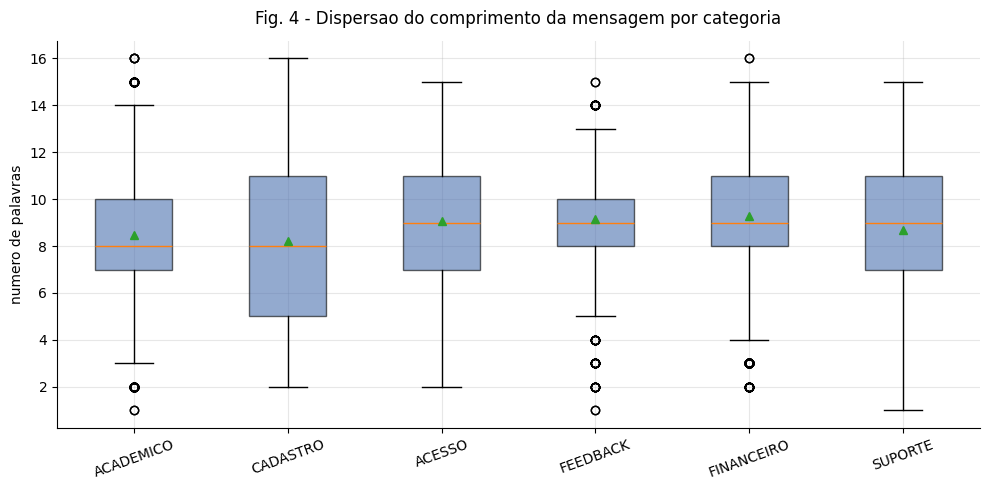

                  count  mean  median   std  min  max
categoria_edubot                                     
ACADEMICO          6009  8.46     8.0  2.51    1   16
ACESSO              995  9.08     9.0  2.22    2   15
CADASTRO           2557  8.20     8.0  3.23    2   16
FEEDBACK           1997  9.17     9.0  2.12    1   15
FINANCEIRO         6450  9.28     9.0  2.61    2   16
SUPORTE            2998  8.67     9.0  2.38    1   15


In [22]:
# --- FIG 4: boxplot do comprimento por categoria ---
ordem = df.groupby("categoria_edubot")["n_palavras"].median().sort_values().index
dados = [df.loc[df["categoria_edubot"] == cat, "n_palavras"].values for cat in ordem]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(dados, labels=ordem, patch_artist=True, showmeans=True)
for caixa in bp["boxes"]:
    caixa.set_facecolor("#4C72B0"); caixa.set_alpha(0.6)
ax.set_title("Fig. 4 - Dispersao do comprimento da mensagem por categoria", fontsize=12, pad=12)
ax.set_ylabel("numero de palavras")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_boxplot_comprimento_categoria.png", dpi=120)
plt.show()

print(df.groupby("categoria_edubot")["n_palavras"]
        .agg(["count", "mean", "median", "std", "min", "max"]).round(2).to_string())

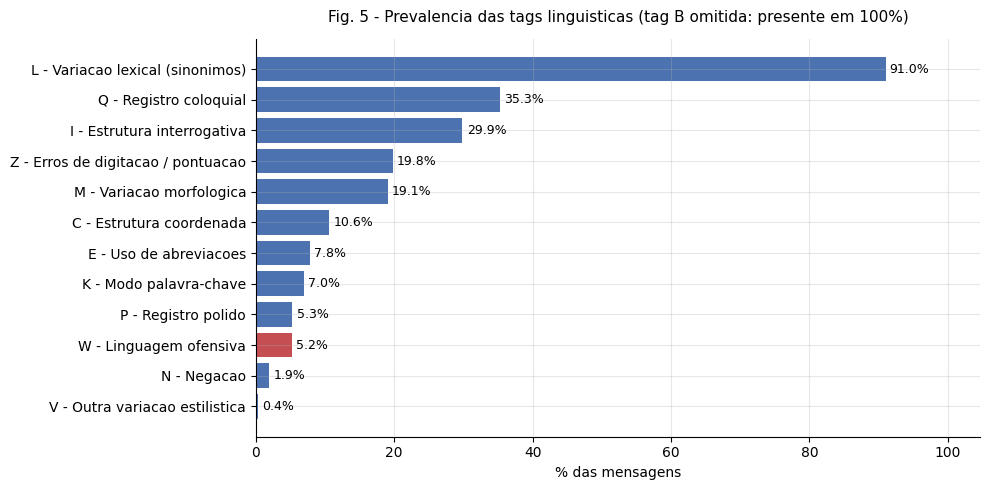

In [23]:
# --- FIG 5: prevalencia das tags linguisticas ---
fig, ax = plt.subplots(figsize=(10, 5))
t = tabela_tags[tabela_tags["tag"] != "B"].sort_values("pct_das_mensagens")
cor = ["#C44E52" if x == "W" else "#4C72B0" for x in t["tag"]]
barras = ax.barh(t["tag"] + " - " + t["descricao"], t["pct_das_mensagens"], color=cor)
ax.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_title("Fig. 5 - Prevalencia das tags linguisticas (tag B omitida: presente em 100%)",
             fontsize=11, pad=12)
ax.set_xlabel("% das mensagens")
ax.set_xlim(0, t["pct_das_mensagens"].max() * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_tags_linguisticas.png", dpi=120)
plt.show()

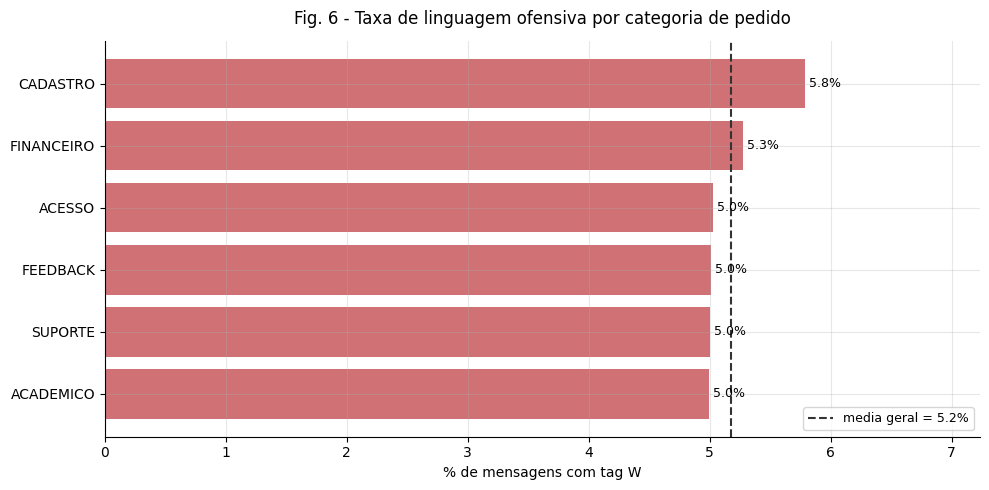

Taxa de ofensa por intencao (top 8):
intent_edubot
financeiro_acompanhar_reembolso    6.93
cadastro_atualizar_dados           6.44
solicitacao_consultar_status       5.70
disciplina_alterar                 5.63
cadastro_trocar_vinculo            5.57
matricula_solicitar                5.49
cadastro_cancelar_vinculo          5.45
financeiro_solicitar_reembolso     5.34


In [24]:
# --- FIG 6: taxa de linguagem ofensiva por categoria ---
taxa = (df.groupby("categoria_edubot")["tem_ofensa"].mean() * 100).sort_values()
media_geral = df["tem_ofensa"].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(taxa.index, taxa.values, color="#C44E52", alpha=0.8)
ax.bar_label(barras, fmt="%.1f%%", padding=3, fontsize=9)
ax.axvline(media_geral, color="#333333", linestyle="--", linewidth=1.5,
           label=f"media geral = {media_geral:.1f}%")
ax.set_title("Fig. 6 - Taxa de linguagem ofensiva por categoria de pedido", fontsize=12, pad=12)
ax.set_xlabel("% de mensagens com tag W")
ax.set_xlim(0, taxa.max() * 1.25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_ofensa_por_categoria.png", dpi=120)
plt.show()

print("Taxa de ofensa por intencao (top 8):")
print((df.groupby("intent_edubot")["tem_ofensa"].mean() * 100)
        .sort_values(ascending=False).head(8).round(2).to_string())

---
## 7. Hipóteses sobre as intenções dos usuários

O TP1 pede pelo menos 3 hipóteses. Formulei quatro a partir dos padrões que vi nos dados.

In [25]:
# Evidencia para H1
print("H1 - comprimento medio por natureza do pedido")
print(df.groupby("natureza")["n_palavras"].agg(["mean", "median", "count"]).round(2).to_string())
print()
print("Extremos por intencao:")
m = df.groupby("intent_edubot")["n_palavras"].mean().sort_values()
print("  mais curtas:", ", ".join(f"{i} ({v:.1f})" for i, v in m.head(3).items()))
print("  mais longas:", ", ".join(f"{i} ({v:.1f})" for i, v in m.tail(3).items()))

H1 - comprimento medio por natureza do pedido
             mean  median  count
natureza                        
academico    8.46     8.0   6009
burocratico  8.98     9.0  10002
relacional   8.87     9.0   4995

Extremos por intencao:
  mais curtas: cadastro_atualizar_dados (6.5), disciplina_trancar (7.9), suporte_atendente_humano (8.1)
  mais longas: feedback_avaliacao (9.5), financeiro_acompanhar_reembolso (9.8), financeiro_politica_reembolso (10.5)


In [26]:
# Evidencia para H2
print("H2 - ofensa: intencoes acima da media geral")
media = df["tem_ofensa"].mean()
taxa_int = df.groupby("intent_edubot")["tem_ofensa"].mean().sort_values(ascending=False)
print(f"media geral = {media*100:.2f}%")
print()
print((taxa_int[taxa_int > media] * 100).round(2).to_frame("pct_ofensa").to_string())

H2 - ofensa: intencoes acima da media geral
media geral = 5.18%

                                 pct_ofensa
intent_edubot                              
financeiro_acompanhar_reembolso        6.93
cadastro_atualizar_dados               6.44
solicitacao_consultar_status           5.70
disciplina_alterar                     5.63
cadastro_trocar_vinculo                5.57
matricula_solicitar                    5.49
cadastro_cancelar_vinculo              5.45
financeiro_solicitar_reembolso         5.34
financeiro_consultar_boleto            5.21


In [27]:
# Evidencia para H3
ruido = df["tem_typo"] | df["tem_coloquial"] | df["tem_abreviacao"]
print(f"H3 - mensagens com ruido de superficie (typo OU coloquial OU abreviacao): "
      f"{ruido.sum()} ({ruido.mean()*100:.1f}%)")
print()
print("Variacao da taxa de ruido entre categorias:")
r = df.assign(ruido=ruido).groupby("categoria_edubot")["ruido"].mean().mul(100).round(2).sort_values()
print(r.to_frame("pct_com_ruido").to_string())
print(f"\namplitude entre categorias: {r.max() - r.min():.2f} pontos percentuais")

H3 - mensagens com ruido de superficie (typo OU coloquial OU abreviacao): 10262 (48.9%)

Variacao da taxa de ruido entre categorias:
                  pct_com_ruido
categoria_edubot               
SUPORTE                   46.90
FINANCEIRO                48.31
CADASTRO                  48.49
FEEDBACK                  49.42
ACADEMICO                 49.96
ACESSO                    51.36

amplitude entre categorias: 4.46 pontos percentuais


In [28]:
# Evidencia para H4
sensiveis = ["CADASTRO", "ACESSO"]
n_sens = df["categoria_edubot"].isin(sensiveis).sum()
print(f"H4 - volume em categorias que operam sobre registro de aluno (CADASTRO + ACESSO): "
      f"{n_sens} ({n_sens/len(df)*100:.1f}%)")
print()
print(df[df["categoria_edubot"].isin(sensiveis)]["intent_edubot"]
        .value_counts().to_frame("n").to_string())

H4 - volume em categorias que operam sobre registro de aluno (CADASTRO + ACESSO): 3552 (16.9%)

                             n
intent_edubot                 
acesso_recuperar_senha     995
cadastro_cancelar_vinculo  918
cadastro_trocar_vinculo    862
cadastro_atualizar_dados   777


### H1 — Pedidos com justificativa tendem a ser mais longos

**Resultado: parcial.**

Por categoria, a diferença é pequena: ACADEMICO 8,46 palavras vs FINANCEIRO 9,28. Por intenção,
fica mais claro: de 6,55 (`cadastro_atualizar_dados`) a 10,53 (`financeiro_politica_reembolso`),
1,6x. Operações diretas são curtas; consultar regra ou acompanhar processo puxa o texto.

O dataset limita a 16 palavras, então em mensagens reais de aluno a diferença provavelmente seria
maior. `n_palavras` pode ser feature auxiliar no TP3, mas o sinal principal continua sendo o texto
(as distribuições se sobrepõem — Fig. 4).

---

### H2 — Hostilidade indica o tipo de pedido

**Resultado: refutada.** Chutei isso antes de olhar os números; os dados não sustentam.

Taxa global de tag `W`: 5,18%. Por intenção, varia de 2,23% a 6,93% (desvio-padrão 0,82 p.p.).
`feedback_reclamacao` deveria estar no topo e fica na média. As tags de estilo foram aplicadas pelo
gerador de forma independente da intenção — não são sinal de urgência.

Implicação principal: o `urgencia_proxy` da seção 5.1 **não serve** como rótulo de urgência. No TP2
preciso de dataset de emoção ou anotação manual. (Mesmo se houvesse correlação, priorizar fila por
hostilidade seria estranho — urgência acadêmica é prazo, não tom.)

---

### H3 — Metade das mensagens tem typo, gíria ou abreviação

**Resultado: confirmada.**

10.262 mensagens (48,9%) com erro de digitação, coloquialismo ou abreviação. A taxa varia pouco
entre categorias (46,9% a 51,4%).

Pra pré-processamento: não dá pra confiar em match exato de string — normalização e n-gramas de
caracteres fazem sentido.

Pra segurança (liga com o TP2): se quase metade das mensagens legítimas já tem grafia irregular,
filtro por palavra proibida não segura — basta errar a grafia (`ignoore as instruçoes anteriores`).
Filtro agressivo demais bloqueia aluno de verdade. Defesa precisa ser semântica, não comparação de
string.

---

### H4 — ~17% dos pedidos tocam cadastro ou acesso do aluno

**Resultado: confirmada.**

CADASTRO + ACESSO = 3.552 mensagens (16,9%): recuperar senha, cancelar/trocar vínculo, atualizar
dados. Não é o maior bloco, mas é relevante — são as intenções onde um sistema real mexeria no
registro de um aluno identificado por parâmetro (matrícula, id). É a superfície de IDOR.

Isso bate com a prioridade que a Patricia documentou em `dfd/analise-cia.md`. No TP2, `/predict`
precisa checar se o aluno autenticado é dono do recurso que quer acessar — autenticado sem
autorização é justamente o cenário de IDOR.


---
## 8. Exportação do dataset tratado e limitações

### 8.1 Resumo do pipeline

| Etapa | O que fiz |
|---|---|
| Ausentes | Nada — zero nulos |
| Duplicatas | Removi pares (`instruction`, `intent`) repetidos |
| Descarte | 4 intenções logísticas sem equivalente acadêmico |
| Mapeamento | 23 intenções → vocabulário EduBot (+3 colunas) |
| Features | Comprimento + tags linguísticas (+10 colunas) |
| Urgência | `urgencia_proxy` heurístico (+1 coluna; refutado na H2) |

Não encontrei frases com rótulos conflitantes.

In [29]:
COLUNAS_FINAIS = [
    "instruction", "flags",
    "intent", "category",
    "intent_edubot", "categoria_edubot", "natureza",
    "n_chars", "n_palavras",
    "tem_ofensa", "tem_typo", "tem_coloquial", "tem_polidez",
    "tem_negacao", "modo_keyword", "tem_abreviacao",
    "urgencia_proxy",
]
df_final = df[COLUNAS_FINAIS].reset_index(drop=True)

SAIDA = DATA_DIR / "edubot_dataset_tratado.csv"
df_final.to_csv(SAIDA, index=False)

print("PIPELINE COMPLETO")
print(f"  bruto             : {len(df_raw):>6} registros x {df_raw.shape[1]} colunas")
print(f"  apos duplicatas   : {n_antes:>6} registros")
print(f"  apos adaptacao    : {len(df_final):>6} registros x {df_final.shape[1]} colunas")
print(f"  retencao          : {len(df_final)/len(df_raw)*100:.1f}% dos registros originais")
print()
print(f"  salvo em          : {SAIDA}")
print(f"  tamanho           : {SAIDA.stat().st_size / 1024**2:.2f} MB")
print()
print("  categorias        :", df_final['categoria_edubot'].nunique())
print("  intencoes         :", df_final['intent_edubot'].nunique())
print()
df_final.head(3)

PIPELINE COMPLETO
  bruto             :  26872 registros x 5 colunas
  apos duplicatas   :  24635 registros
  apos adaptacao    :  21006 registros x 17 colunas
  retencao          : 78.2% dos registros originais

  salvo em          : data/edubot_dataset_tratado.csv
  tamanho           : 3.49 MB

  categorias        : 6
  intencoes         : 23



,instruction,flags,intent,category,intent_edubot,categoria_edubot,natureza,n_chars,n_palavras,tem_ofensa,tem_typo,tem_coloquial,tem_polidez,tem_negacao,modo_keyword,tem_abreviacao,urgencia_proxy
0,question about cancelling order {{Order Number}},B,cancel_order,ORDER,disciplina_trancar,ACADEMICO,academico,48,6,False,False,False,False,False,False,False,media
1,i have a question about cancelling oorder {{Order Number}},BQZ,cancel_order,ORDER,disciplina_trancar,ACADEMICO,academico,58,9,False,True,True,False,False,False,False,media
2,i need help cancelling puchase {{Order Number}},BLQZ,cancel_order,ORDER,disciplina_trancar,ACADEMICO,academico,47,7,False,True,True,False,False,False,False,media


In [30]:
print("VERIFICACAO FINAL DE INTEGRIDADE")
verificacoes = {
    "sem nulos":                       df_final.isna().sum().sum() == 0,
    "acima de 500 amostras":           len(df_final) >= 500,
    "coluna de texto presente":        "instruction" in df_final.columns,
    "coluna de categoria presente":    "categoria_edubot" in df_final.columns,
    "todas as categorias com n>=100":  df_final["categoria_edubot"].value_counts().min() >= 100,
    "comprimento sempre positivo":     (df_final["n_palavras"] > 0).all(),
}
for k, v in verificacoes.items():
    print(f"  [{'OK ' if v else 'X  '}] {k}")
assert all(verificacoes.values()), "Falha na verificacao de integridade"
print("\nDataset pronto para a modelagem preditiva do TP3.")

VERIFICACAO FINAL DE INTEGRIDADE
  [OK ] sem nulos
  [OK ] acima de 500 amostras
  [OK ] coluna de texto presente
  [OK ] coluna de categoria presente
  [OK ] todas as categorias com n>=100
  [OK ] comprimento sempre positivo

Dataset pronto para a modelagem preditiva do TP3.


### 8.2 Limitações

1. **Dataset sintético** — intenções quase uniformes (~1.000 cada), não reflete sazonalidade real
   (rematrícula concentra demanda em matrícula e nota).
2. **Inglês** — treino fica em inglês (orientação em aula); tradução pro aluno fica na resposta (TP2+).
3. **Rótulos adaptados, texto não** — frases continuam de e-commerce; termos como *dispensa de
   disciplina* não aparecem. No TP2 quero combinar com logs universitários.
4. **Sem urgência utilizável** — `urgencia_proxy` testado na H2 e refutado. Coluna mantida só como
   registro; não usar pra treino.
5. **Hipóteses observacionais** — sem teste estatístico formal ainda (TP2).

### 8.3 Próximos passos

- **TP2:** testes estatísticos em H1–H4; segundo dataset (universitário e/ou emoção); defesas da API.
- **TP3:** definir modelo preditivo.
- **TP4/TP5:** agente + pentest.
